<a href="https://colab.research.google.com/github/basnaa1212/anime_gan/blob/main/anime_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/mydrive',force_remount=True)

Mounted at /content/mydrive


In [2]:
import random
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

In [3]:
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn as nn

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [5]:
class Generator(nn.Module):
  def __init__(self,noice_dimension=128):
    super().__init__()
    self.model= nn.Sequential(

        #Layer 1
        nn.ConvTranspose2d(
            in_channels=noice_dimension,
            out_channels =512,
            kernel_size=4,
            stride=1,
            padding=0,
            bias=False
        ),
        nn.BatchNorm2d(512),
        nn.ReLU(True),

        #Layer 2
        nn.ConvTranspose2d(
        in_channels=512,
        out_channels=256,
        kernel_size=4,
        stride=2,
        padding=1,
        bias=False
      ),

      nn.BatchNorm2d(256),

      nn.ReLU(True),

      #Layer 2
      nn.ConvTranspose2d(
        in_channels=256,
        out_channels=128,
        kernel_size=4,
        stride=2,
        padding=1,
        bias=False
      ),


      nn.BatchNorm2d(128),
      nn.ReLU(True),

        #layer 4
      nn.ConvTranspose2d(
      in_channels=128,
      out_channels=64,
      kernel_size=4,
      stride=2,
      padding=1,
      bias=False
      ),

      nn.BatchNorm2d(64),
      nn.ReLU(True),

        #layer 5
      nn.ConvTranspose2d(
      in_channels=64,
      out_channels=3,
      kernel_size=4,
      stride=2,
      padding=1,
      bias=False
      ),

      #Final layer use tanh since gan producec valu form -1 to 1
      nn.Tanh()
    )

  def forward(self,x):
        return self.model(x)

In [6]:
generator=Generator().to(device)
checkpoint=torch.load("/content/mydrive/MyDrive/gan_epoch_13_new.pth",
    map_location=device
)
generator.load_state_dict(checkpoint["generator"])

<All keys matched successfully>

In [7]:
generator.eval()

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [8]:
with torch.no_grad():
  z=torch.randn(1,128,1,1,device=device)
  fake=generator(z)

In [9]:
print(fake.shape)

torch.Size([1, 3, 64, 64])


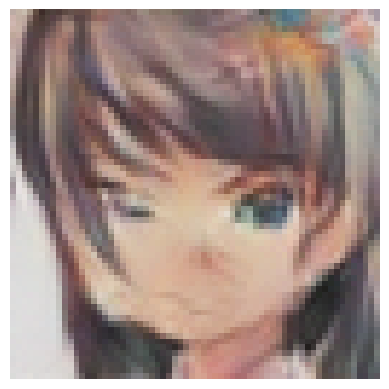

In [10]:
import matplotlib.pyplot as plt
img=fake.squeeze(0).cpu()
img=img.permute(1,2,0)
img=(img+1)/2
img=img.clamp(0,1)
plt.imshow(img)
plt.axis("off")
plt.show()